# PE2 Analysis (VpiL / IL / ER)
Determine `src/wafer_analyzer.py`, This Jupyter notebook only show result.  Run -> Run All Cells.

In [1]:
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))
import wafer_analyzer as wa

FOLDER = 'dat/HY202103'
WAFERS = ['D07', 'D08', 'D23', 'D24']
data = wa.load(FOLDER, WAFERS)
length_map = wa.build_length_map(FOLDER, WAFERS)

## Summary
Median VpiL / IL / ER per wafer and band, with Center/Edge medians and VpiL target pass rate.

In [2]:
wa.summary_table(data, length_map)

,Wafer,Band,n,VpiL (V.cm),IL (dB),ER (dB),VpiL_Center (V.cm),VpiL_Edge (V.cm)
0,D07,LMZC,14,1.246,-9.807,33.403,1.178,1.295
1,D08,LMZC,13,1.273,-10.125,33.935,1.313,1.158
2,D08,LMZO,14,1.096,-6.525,27.830,1.059,1.299
3,D23,LMZO,15,1.364,-6.636,27.750,1.338,1.376
4,D24,LMZO,16,1.413,-6.441,27.501,1.644,1.280


## Select Wafer / Date / Die - level

In [3]:
wafers = wa.list_wafers(data)
print(f"Total wafer: {wafers}")
print("=" * 50)

for wafer in wafers:
    dates = wa.list_dates(data, wafer)
    print(f"[{wafer}] Dates: {dates}")

    for date in dates:
        dies = wa.list_dies(data, wafer, date)
        print(f"{date} Dies: {dies}")

    print("-" * 50)

Total wafer: ['D07', 'D08', 'D23', 'D24']
[D07] Dates: ['20190715']
20190715 Dies: [('LMZC', -4, -1), ('LMZC', -3, -3), ('LMZC', -3, 0), ('LMZC', -3, 2), ('LMZC', -1, -3), ('LMZC', -1, -1), ('LMZC', -1, 3), ('LMZC', 0, -4), ('LMZC', 0, 0), ('LMZC', 0, 2), ('LMZC', 2, -3), ('LMZC', 2, -1), ('LMZC', 2, 2), ('LMZC', 3, 0)]
--------------------------------------------------
[D08] Dates: ['20190526', '20190712']
20190526 Dies: [('LMZO', -4, -1), ('LMZO', -3, -3), ('LMZO', -3, 0), ('LMZO', -3, 2), ('LMZO', -1, -3), ('LMZO', -1, -1), ('LMZO', -1, 3), ('LMZO', 0, -4), ('LMZO', 0, 0), ('LMZO', 0, 2), ('LMZO', 2, -3), ('LMZO', 2, -1), ('LMZO', 2, 2), ('LMZO', 3, 0)]
20190712 Dies: [('LMZC', -4, -1), ('LMZC', -3, -3), ('LMZC', -3, 0), ('LMZC', -3, 2), ('LMZC', -1, -3), ('LMZC', -1, -1), ('LMZC', -1, 3), ('LMZC', 0, -4), ('LMZC', 0, 0), ('LMZC', 0, 2), ('LMZC', 2, -3), ('LMZC', 2, -1), ('LMZC', 2, 2), ('LMZC', 3, 0)]
--------------------------------------------------
[D23] Dates: ['20190531', '201

## Select Wafer,Date,Band,Die

In [4]:
WAFER = 'D23'
DATE  = '20190603'
BAND  = 'LMZO'        # LMZC(C-band) 또는 LMZO(O-band)
DIE   = (-1, 3)      # (열, 행) - VpiL 곡선 볼 다이

## CSV Data file

In [5]:
wa.display_die_table(data, length_map, WAFER, DATE, BAND, *DIE)

# (선택) 그래프를 구성하는 X, Y축 원본 데이터까지 표로 보고 싶을 때
# wa.display_die_table(data, length_map, WAFER, DATE, BAND, *DIE, show_raw=True)

[Summary] D23 / LMZO / Coord: (-1, 3)


,Wafer,Date,Band,Column,Row,ER (dB),IL (dB),VpiL (V*cm)
0,D23,20190603,LMZO,-1,3,27.74635,-6.931001,1.112975


## plot, fitting, vpil

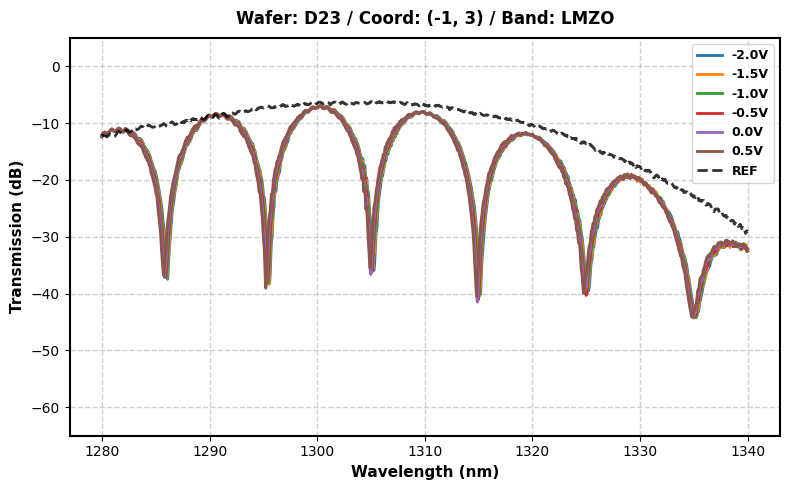

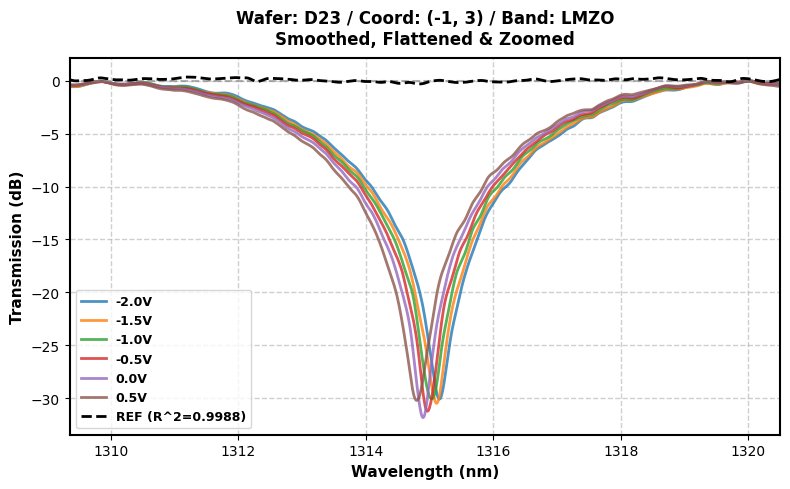

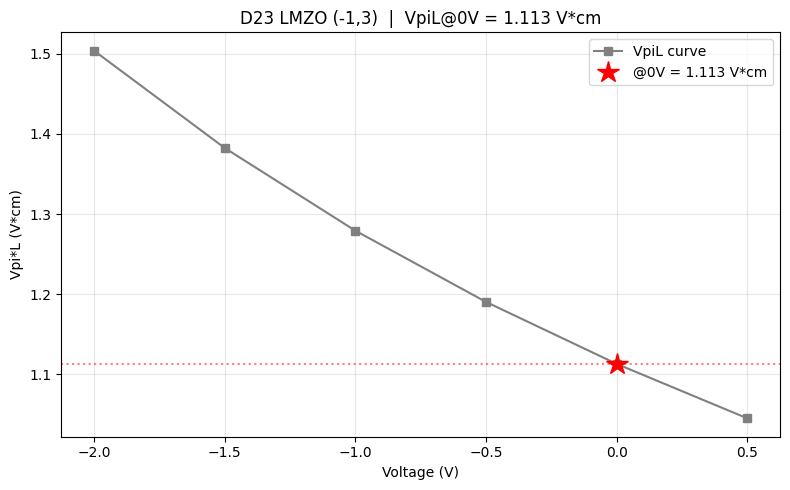

In [6]:
wa.plot_die_plot(data, length_map, WAFER, DATE, BAND, *DIE)
wa.plot_die_fitting(data, length_map, WAFER, DATE, BAND, *DIE)
wa.plot_die_vpil(data, length_map, WAFER, DATE, BAND, *DIE)

## Wafer Map(ER,IL,VpiL)

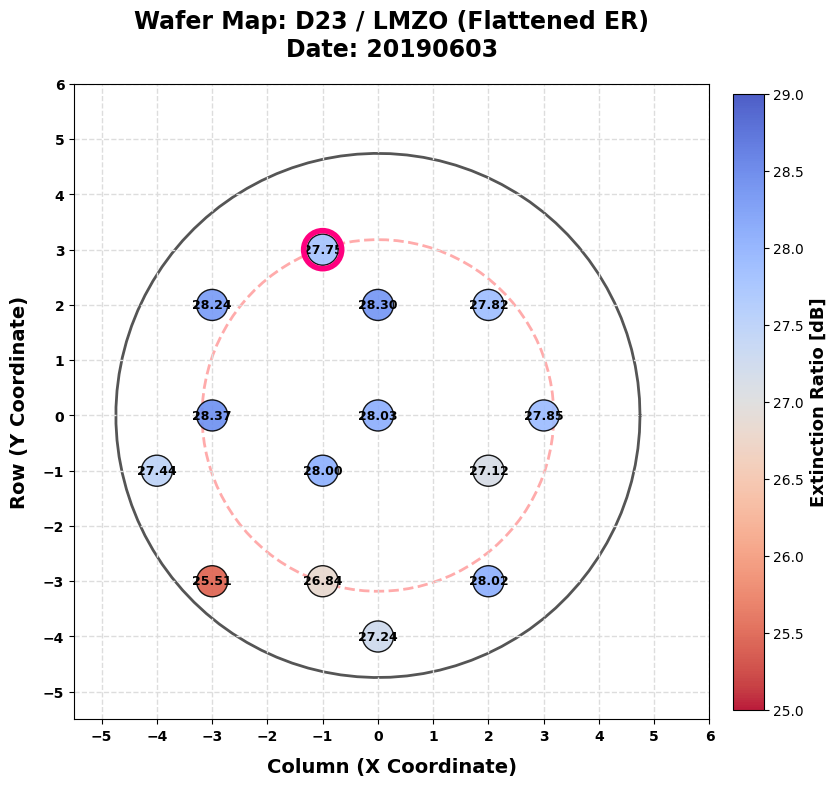

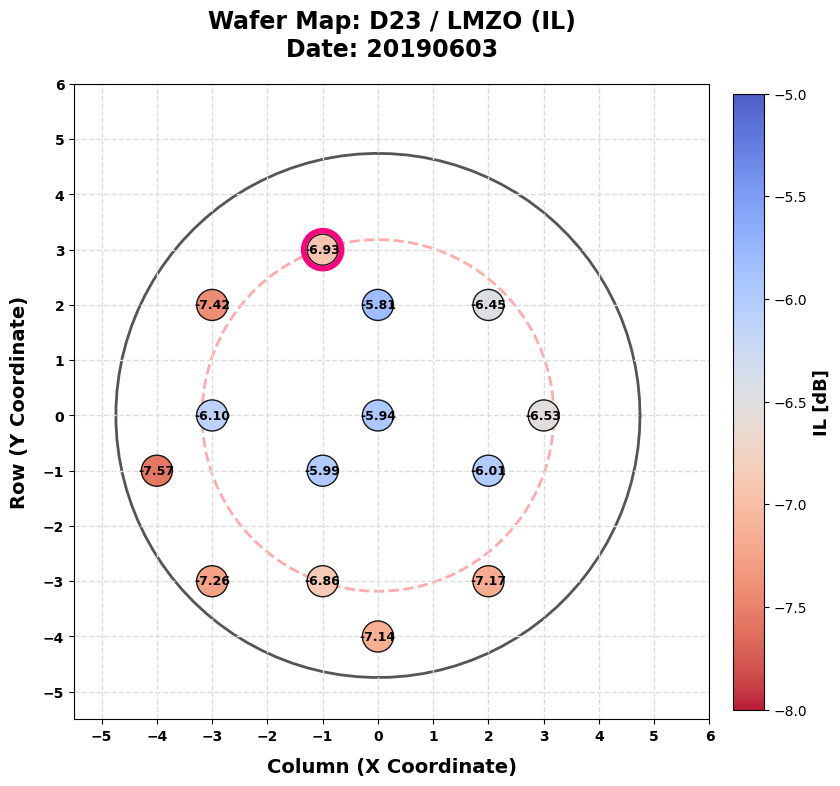

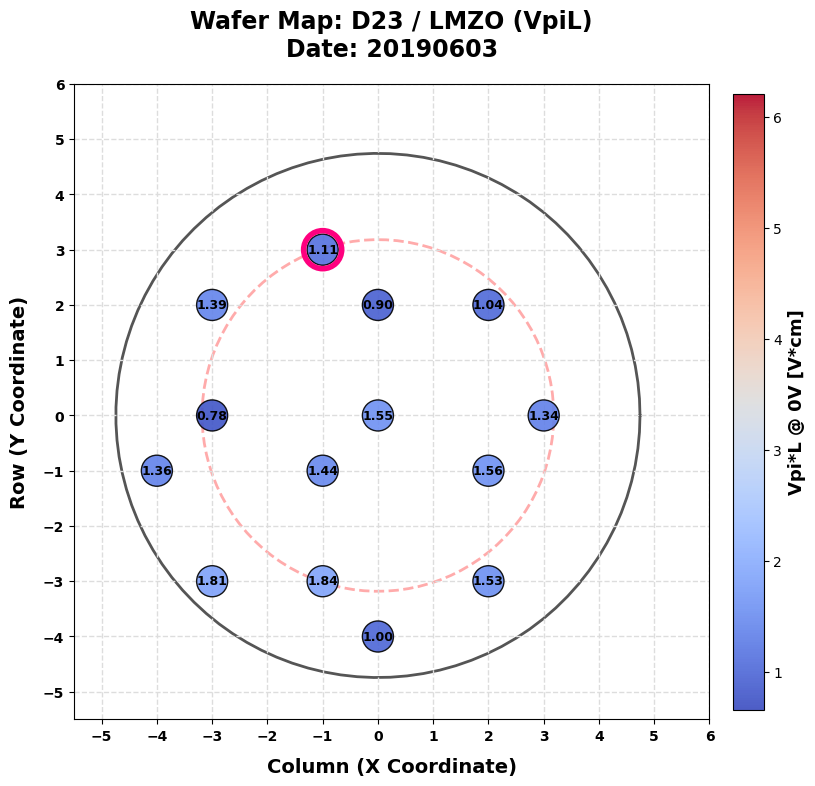

In [7]:
wa.plot_wafer_map(data, length_map, WAFER, DATE, BAND, 'er', *DIE)
wa.plot_wafer_map(data, length_map, WAFER, DATE, BAND, 'il', *DIE)
wa.plot_wafer_map(data, length_map, WAFER, DATE, BAND, 'vpil', *DIE)


## Box(ER,IL,VpiL)

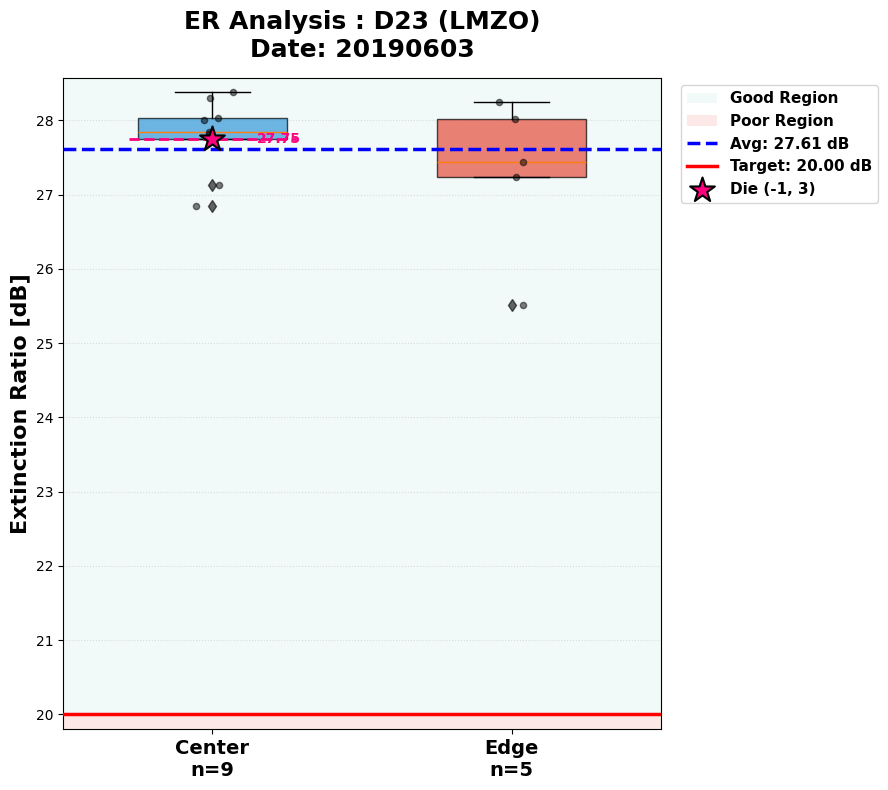

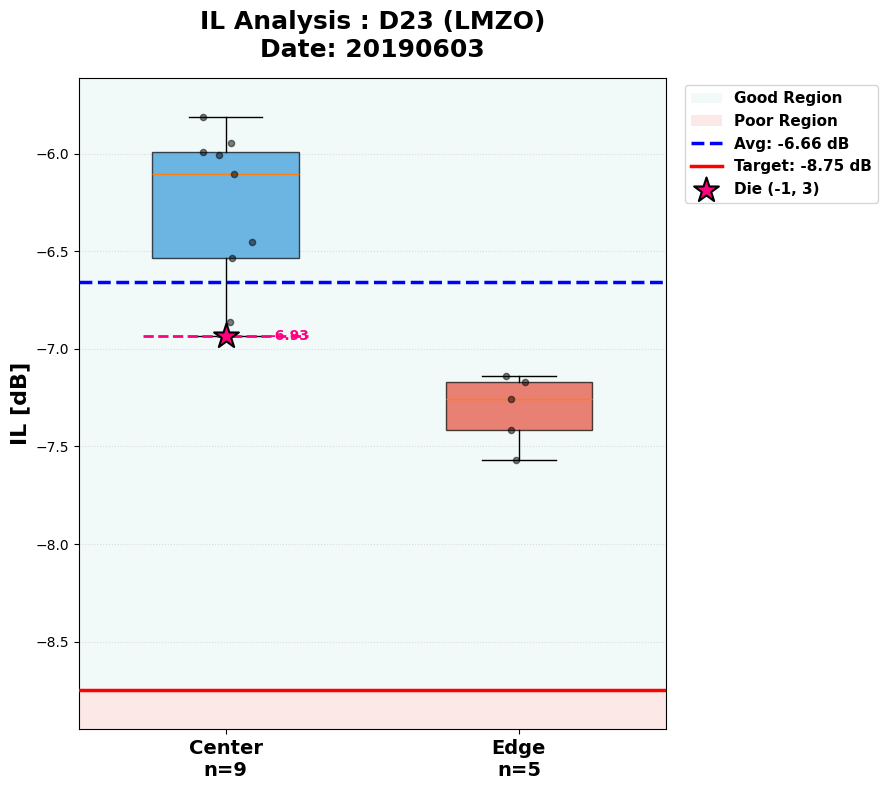

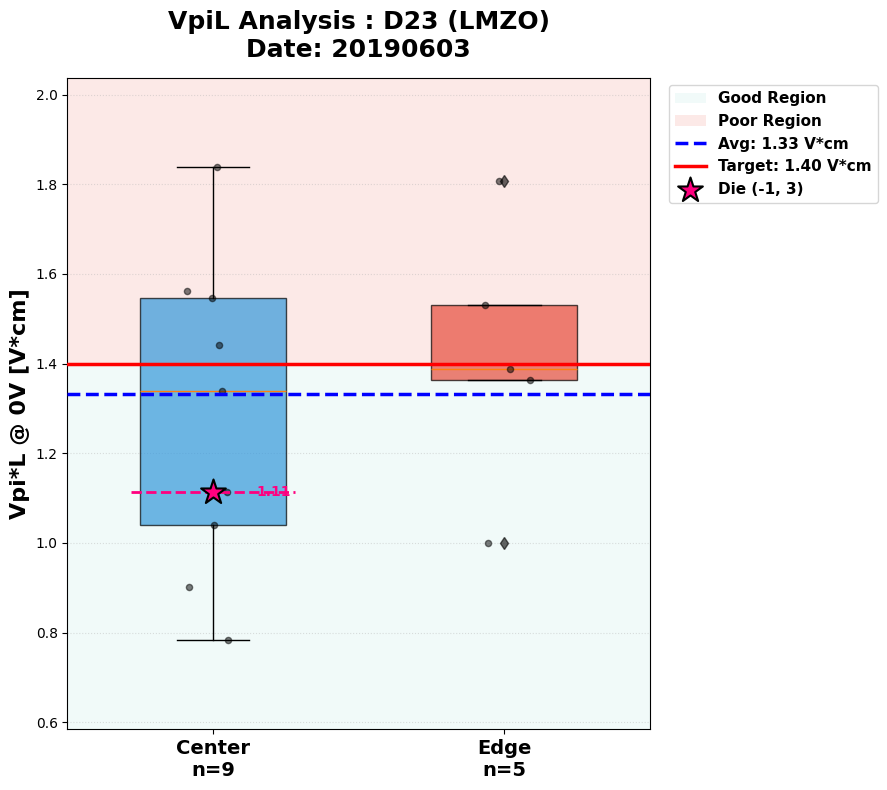

In [8]:
wa.plot_box(data, length_map, WAFER, DATE, BAND, 'er',*DIE)
wa.plot_box(data, length_map, WAFER, DATE, BAND, 'il',*DIE)
wa.plot_box(data, length_map, WAFER, DATE, BAND, 'vpil',*DIE)